Task 2

IMDB Dataset of 50K Movie Reviews: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

This dataset contains 50,000 movie reviews labeled as positive or negative. Each example is a piece of natural language text which forms a sequence of words. The order of words in a review is meaningful and contributes to the overall sentiment meaning of the text.

**Why sequential models are needed** \
The task is to given a movie review to predict whether the sentiment is positive or negative. Sequence models are needed to solve this problem because RNNs process text token by token and maintain a hidden state that captures context from previous words. Traditional feed-forward models with bag-of-words or TF-IDF representations ignore word order and temporarily dependencies within the text. This leads to information loss in cases involving negotiation and long-range context. Since RNNs process text token by token, it makes them suited for modeling sequential dependencies in language. More advanced variants like LSTMs and GRUs improve the ability for long-range dependencies and mitigate vanishing gradient problems with vanilla RNNs.

**RNN framework** \
The framework I will be using is PyTorch. PyTorch will be good for custom RNN/LSTM/GRU models and have native support for embedding layers and sequence models. PyTorch provides a flexible framework for implementing RNN-based architectures with word embeddings, making it suitable for this problem.


Part 1

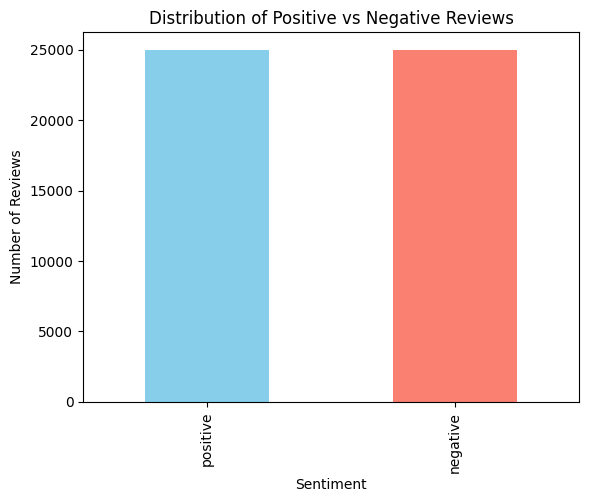

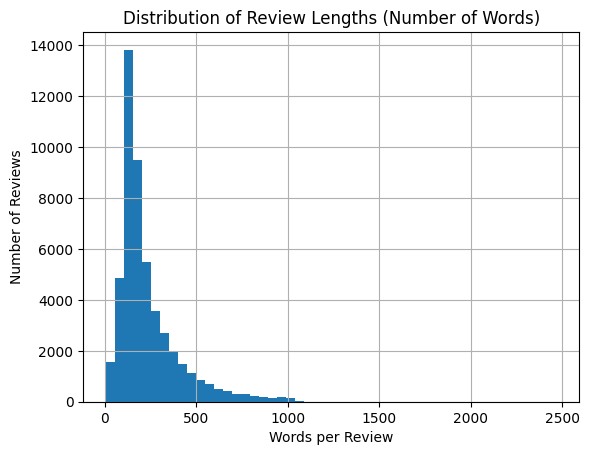

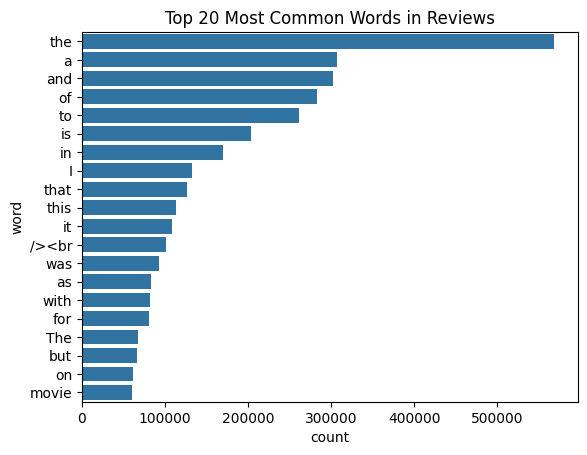

In [11]:
# data visualization
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

df = pd.read_csv("IMDB_Dataset[1].csv")

# class balance
df["sentiment"].value_counts().plot(kind="bar", color=["skyblue","salmon"])
plt.title("Distribution of Positive vs Negative Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

# length distribution
df["review_length"] = df["review"].apply(lambda x: len(x.split()))
df["review_length"].hist(bins=50)
plt.title("Distribution of Review Lengths (Number of Words)")
plt.xlabel("Words per Review")
plt.ylabel("Number of Reviews")
plt.show()

# most common words
print()
words = Counter(" ".join(df["review"]).split())
common_words = words.most_common(20)

words_df = pd.DataFrame(common_words, columns=["word","count"])
sns.barplot(x="count", y="word", data=words_df)
plt.title("Top 20 Most Common Words in Reviews")
plt.show()

The data visualization before preprocessing shows that there is an even distribution of positive and negative words. This means that the dataset is balanced so the accuracy becomes meaningful when computed and there doesn't have to be class weightings. The distribution of review length shows that the distribution is right skewed with most reviews being between 100-400 words. There is a long tail reaching above 1000 words and a few outliers near 2500 words. This shows that reviews vary in length and very long reviews are rare but exist. The most common word in the dataset is “the”, followed by other high-frequency function words such as “a”, “and”, and “of”. These are stop words, which are common grammatical words that appear frequently but carry little semantic meaning. Their dominance in the frequency distribution shows that raw text contains many non-informative tokens. The uppercase “The” among less common words suggests inconsistency in capitalization prior to preprocessing.

In [9]:
# preprocess data
import re
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

'''
Text cleaning
- convert to lowercase
- removes HTML tags
- remove non-alphabet characters

Parameters:
  text: raw review string

Returns:
  cleaned text containing only lowercase alphabetic characters and spaces
'''
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

# applying cleaning to reviews
df["review"] = df["review"].apply(clean_text)

# convert sentiment labels to binary numeric format - positive 1 - negative 0
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})

# split into train validation test splits
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)

# tokenization
'''
Splitting sentences into tokens - words

Parameters:
  text: cleaned review string

Return:
  list[str]: list of word tokens
'''
def tokenize(text):
    return text.split()

# tokenize only training data to avoid data leakage
train_tokens = train_df["review"].apply(tokenize)

# build vocabulary from training set word frequencies
vocab_size = 20000
counter = Counter([w for tokens in train_tokens for w in tokens])

# assign integer IDs to most frequent words
vocab = {word: i+2 for i, (word, freq) in enumerate(counter.most_common(vocab_size-2))}
vocab["<PAD>"] = 0 # padding
vocab["<UNK>"] = 1 # unknown words

'''
Convert list of word tokens into a list of integer indicies
Unknown words are mapped <UNK>

Parameters:
  tokens: tokenized review text

Returns:
  list of vocabulary indicies
'''
def encode(tokens):
    return [vocab.get(w, vocab["<UNK>"]) for w in tokens]

max_len = 100 # max review length - pad to this

'''
Pad or truncate token sequence to fixed length
Sequences longer than max_len are truncated
Shorter sequences are padded with <PAD> tokens (0)

Parameters:
  seq: encoded token sequence

Returns:
  fixed-length sequence of length max_len
'''
def pad_seq(seq):
    return seq[:max_len] + [0] * max(0, max_len - len(seq))

# dataset
'''
PyTorch Dataset for IMDB sentiment classification

Each item returns padded sequence of word indicies and binary sentiment label
'''
class IMDBDataset(Dataset):
    '''
    Parameters:
      df: dataframe containing review and sentiment columns
    '''
    def __init__(self, df):
        self.texts = df["review"].apply(tokenize).apply(encode).apply(pad_seq).tolist()
        self.labels = df["sentiment"].tolist()

    '''
    Returns:
      number of samples in the dataset
    '''
    def __len__(self):
        return len(self.labels)

    '''
    Retrieve one data sample

    Parameters:
      idx: index of the sample

    Returns:
      (tensor, tensor): (padded_token_sequence, sentiment_label)
    '''
    def __getitem__(self, idx):
        return torch.tensor(self.texts[idx]), torch.tensor(self.labels[idx])

The dataset needs to be preprocessed first. The text is first preprocessed through lowercasing, removal of HTML tags, and removal of non-alphabetic characters. The cleaned text is tokenized, converted into integer indices using a vocabulary built from the training set, and padded or truncated to a fixed sequence length. Although many reviews exceed 100 words, max_len = 100 to balance computational efficiency and information retention. Since sentiment is often expressed early in reviews, truncating beyond 100 tokens reduces training cost while preserving key contextual information.

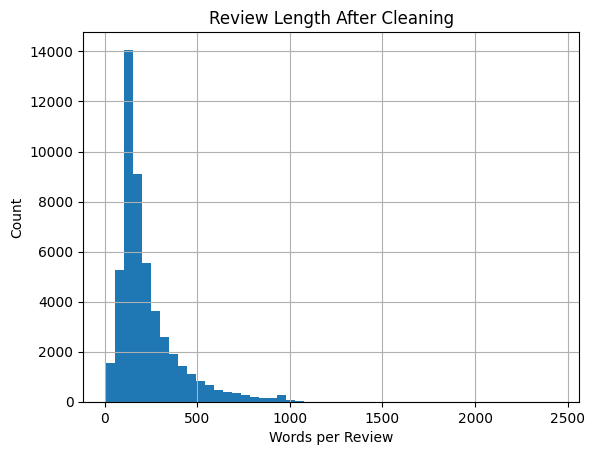

Average length: 225.18978
95th percentile: 575.0



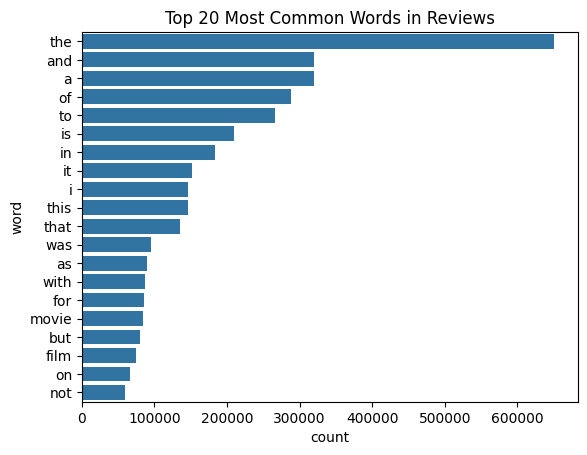

In [10]:
# data visualization after cleaning

# distribution length
df["clean_review"] = df["review"].apply(clean_text)
df["clean_length"] = df["clean_review"].apply(lambda x: len(x.split()))

df["clean_length"].hist(bins=50)
plt.title("Review Length After Cleaning")
plt.xlabel("Words per Review")
plt.ylabel("Count")
plt.show()

print("Average length:", df["clean_length"].mean())
print("95th percentile:", df["clean_length"].quantile(0.95))

# most common words after preprocessing
print()
words = Counter(" ".join(df["review"]).split())
common_words = words.most_common(20)

words_df = pd.DataFrame(common_words, columns=["word","count"])
sns.barplot(x="count", y="word", data=words_df)
plt.title("Top 20 Most Common Words in Reviews")
plt.show()

The data visualization after preprocessing shows a very similar length distribution to before. Removing HTML and punctuation did not change the review length by much and the semantic content remains similar length. After preprocessing, the most frequent words remain common function words such as “the”, “a”, and “and”. This shows that while normalization reduced vocabulary redundancy (eliminating separate tokens for “The” and “the”), stop words were retained. In sequence models like RNNs, stop words are not always removed because they contribute to syntactic structure and contextual flow, which the model can learn to weight appropriately through embeddings.

Epoch 1
Train Set - Loss: 0.6957, Accuracy: 0.5163, F1: 0.4985
Validation Set - Loss: 0.6917, Accuracy: 0.5302, F1: 0.4796
Epoch 2
Train Set - Loss: 0.6846, Accuracy: 0.5519, F1: 0.5326
Validation Set - Loss: 0.6830, Accuracy: 0.5387, F1: 0.4938
Epoch 3
Train Set - Loss: 0.6702, Accuracy: 0.5844, F1: 0.5783
Validation Set - Loss: 0.6968, Accuracy: 0.4973, F1: 0.5267
Epoch 4
Train Set - Loss: 0.6701, Accuracy: 0.5819, F1: 0.5629
Validation Set - Loss: 0.6915, Accuracy: 0.5750, F1: 0.5621
Epoch 5
Train Set - Loss: 0.6258, Accuracy: 0.6455, F1: 0.6423
Validation Set - Loss: 0.7215, Accuracy: 0.5125, F1: 0.4830



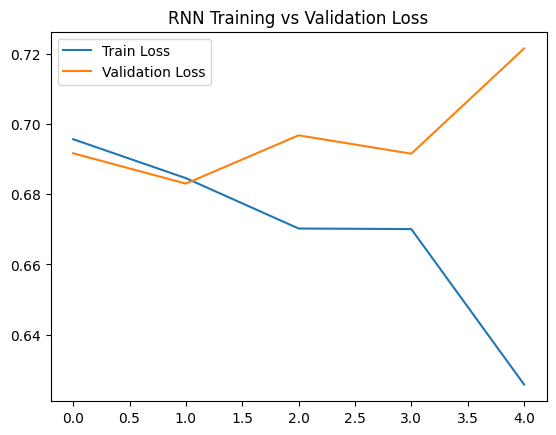


Final Test Evaluation
Test Set - Loss: 0.7180, Accuracy: 0.5101, F1: 0.4801


In [13]:
# implement RNN using existing framework

from sklearn.metrics import accuracy_score, f1_score

# create dataloaders for mini-batch training
train_loader = DataLoader(IMDBDataset(train_df), batch_size=64, shuffle=True)
val_loader = DataLoader(IMDBDataset(val_df), batch_size=64)
test_loader = DataLoader(IMDBDataset(test_df), batch_size=64)

'''
Vanilla RNN-based classifier for binary sentiment prediction

Architecture:
- Embedding layer
- RNN layer
- Fully connected output layer
- Sigmoid activation for probability output
'''
class RNNClassifier(nn.Module):
    '''
    Parameters:
      vocab_size: size of vocabulary
      embed_dim: dimensionality of word embeddings
      hiddem_dim: dimensionality of RNN hidden state
    '''
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim) # word embeddings
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, nonlinearity="tanh")
        self.fc = nn.Linear(hidden_dim, 1) # final classification layer
        self.sigmoid = nn.Sigmoid() # sigmoid for binary classification

    '''
    Parameters:
      x: input tensor of shape (batch_size, seq_len)

    Return:
      predicted probabilities of shape
    '''
    def forward(self, x):
        emb = self.embedding(x) # (batch, seq_len, embed_dim)
        rnn_outputs, h_n = self.rnn(emb) # h_n: (num_layers, batch, hidden_dim)

        # use final hidden state of last RNN layer as sentence representation
        logits = self.fc(h_n[-1]) # (batch, 1)
        probs = self.sigmoid(logits) # (batch, 1)
        return probs.squeeze(1) # (batch,)

# training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RNNClassifier(len(vocab)).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

'''
Runs one epoch of training or evaluation

Parameters:
  model: embedding layer
  loader: DataLoader providing mini-batches
  optimizer: updates models weights
  criterion: loss function
  train: true - model trained, false - model evaluated
Returns:
  average loss over epoch
  accuracy score
  F1 score
'''
def run_epoch(model, loader, optimizer=None, criterion=None, train=True):
    # set model mode
    model.train() if train else model.eval()

    # track total loss and collect predictions/labels for metrics
    total_loss = 0
    preds_all = [] # stores predicted class labels (0 or 1) for whole epoch
    labels_all = [] # stores ground-truth labels for whole epoch

    # enable/disable gradient computation depending on training or evaluation phase
    # saves memory and speeds up validation/testing
    with torch.set_grad_enabled(train):
        for x, y in loader:
            # move mini-batch to GPU if available
            x = x.to(device) # (batch_size, seq_len)
            y = y.float().to(device) # (batch_size,)

            # forward pass - compute predicted probabilites
            preds = model(x)
            loss = criterion(preds, y) #compute BCE

            if train:
                optimizer.zero_grad() # clear old gradients from previous step
                loss.backward() # backprop - compute gradients
                optimizer.step() # update model parameters

            total_loss += loss.item()

            # convert probabilities to class labels
            preds_all.extend((preds > 0.5).cpu().numpy())
            labels_all.extend(y.cpu().numpy())

    acc = accuracy_score(labels_all, preds_all)
    f1 = f1_score(labels_all, preds_all)
    return total_loss / len(loader), acc, f1

# training loop
train_losses, val_losses = [], []

for epoch in range(5):
    # run one full epoch over training data - backpropagation
    train_loss, train_acc, train_f1 = run_epoch(model, train_loader, optimizer, criterion, train=True)

    # run one full epoch over validation data - no gradient updates
    val_loss, val_acc, val_f1 = run_epoch(model, val_loader, optimizer, criterion, train=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print("Epoch", epoch+1)
    print(f"Train Set - Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}, F1: {train_f1:.4f}")
    print(f"Validation Set - Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}, F1: {val_f1:.4f}")

# plot loss curves
print()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("RNN Training vs Validation Loss")
plt.show()

# final test evaluation
test_loss, test_acc, test_f1 = run_epoch(model, test_loader, optimizer, criterion, train=False)
print()
print("Final Test Evaluation")
print(f"Test Set - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}, F1: {test_f1:.4f}")

In this implementation, a vanilla Recurrent Neural Network (RNN) is used for sentiment classification on the IMDb dataset. Each movie review is treated as a sequence of tokens. After the data is preprocessed, an embedding layer then maps each token to a dense vector representation, allowing the model to learn semantic relationships between words.

The embedded sequences are passed through a vanilla RNN cell that uses the hyperbolic tangent (tanh) activation function at each time step. The tanh activation introduces non-linearity and keeps hidden state values bounded between -1 and 1, which helps stabilize training. However, vanilla RNNs have the problem of the vanishing gradient, which makes them less effective at capturing long-range dependencies in long movie reviews. The final hidden state of the RNN is used as a summary representation of the entire review and is passed through a fully connected layer followed by a sigmoid activation function to produce a probability of positive sentiment.

Model performance is evaluated using accuracy and F1-score on both the validation and test sets. Accuracy is chosen because sentiment classification is a binary classification task and accuracy provides an intuitive measure of overall correctness. However, accuracy alone can be misleading when the model is biased toward one class. Therefore, the F1-score is also used, as it balances precision and recall and provides a more informative measure of performance when class predictions are uneven. Evaluating both validation and test performance allows us to see the generalization during training and gives an unbiased estimate of final model performance.

Training and validation loss curves are visualized to analyze convergence behavior and detect overfitting. From the results, training accuracy increases monotonically, showing that the model is learning useful patterns from the training data. Validation accuracy also improves overall, showing that the model generalizes to unseen data. However, at epoch 4, training accuracy increases while validation accuracy decreases, indicating overfitting. This is also reflected in the loss curves, where training loss decreases steadily while validation loss spikes. The subsequent drop in validation loss at epoch 5 shows some instability in training, which is usual for vanilla RNNs.

The final test accuracy closely matches the validation accuracy, indicating that the validation split is representative of the test data. The lower F1-score compared to accuracy suggests that the model is biased toward one class, leading to unbalanced precision and recall. This shows that while the model can predict the overall sentiment correctly, it struggles to capture both positive and negative classes equally well.

Part 2


Training RNN
------------------------------
Epoch 1
Train Set - Loss: 0.6962, Accuracy: 0.5120, F1: 0.5133
Validation Set - Loss: 0.6882, Accuracy: 0.5397, F1: 0.6092
Epoch 2
Train Set - Loss: 0.6859, Accuracy: 0.5480, F1: 0.5554
Validation Set - Loss: 0.6889, Accuracy: 0.5495, F1: 0.5923
Epoch 3
Train Set - Loss: 0.6721, Accuracy: 0.5806, F1: 0.5837
Validation Set - Loss: 0.6828, Accuracy: 0.5643, F1: 0.5721
Epoch 4
Train Set - Loss: 0.6579, Accuracy: 0.6027, F1: 0.5947
Validation Set - Loss: 0.6873, Accuracy: 0.5597, F1: 0.5455
Epoch 5
Train Set - Loss: 0.6349, Accuracy: 0.6351, F1: 0.6299
Validation Set - Loss: 0.6704, Accuracy: 0.6138, F1: 0.6354

Training LSTM
------------------------------
Epoch 1
Train Set - Loss: 0.6921, Accuracy: 0.5271, F1: 0.5133
Validation Set - Loss: 0.6863, Accuracy: 0.5575, F1: 0.6535
Epoch 2
Train Set - Loss: 0.6680, Accuracy: 0.6013, F1: 0.5847
Validation Set - Loss: 0.6716, Accuracy: 0.5665, F1: 0.4997
Epoch 3
Train Set - Loss: 0.5498, Accuracy: 0.72

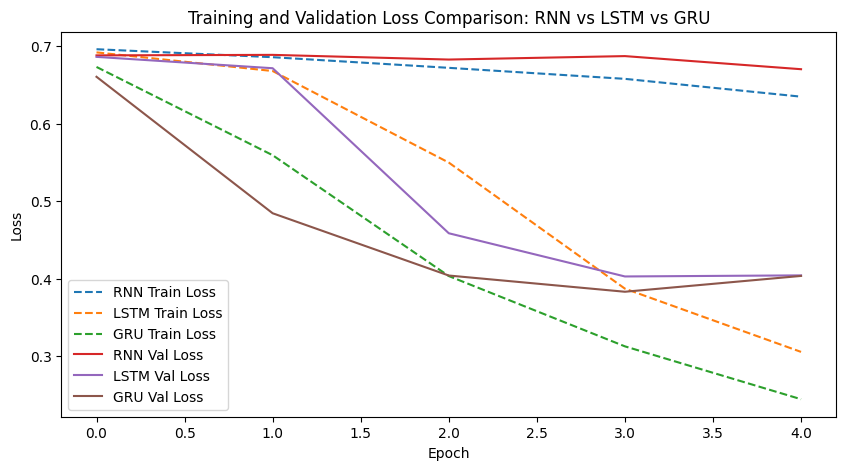

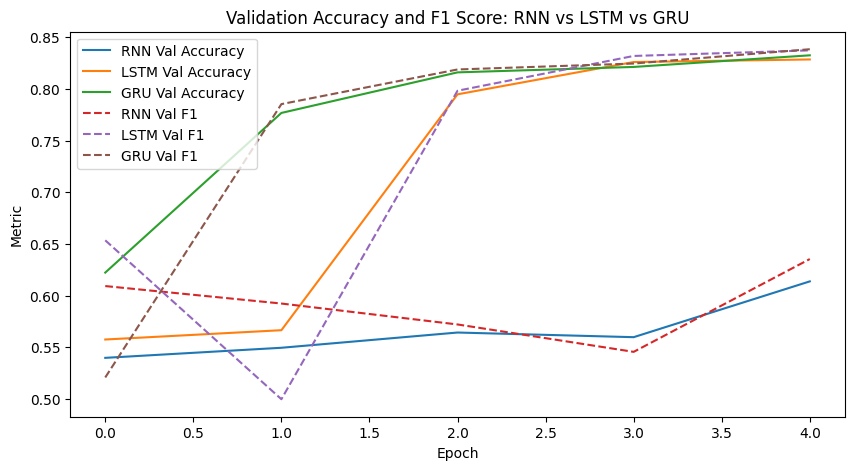


Final Test Results
RNN  - Loss: 0.6859, Accuracy: 0.6020, F1: 0.6166
LSTM - Loss: 0.4055, Accuracy: 0.8308, F1: 0.8369
GRU  - Loss: 0.3982, Accuracy: 0.8370, F1: 0.8397


In [15]:
# update with LSTM first
class LSTMClassifier(nn.Module):
    '''
    Paramters:
      vocab_size: size of vocabulary
      emded_dim: dimension of word embeddings
      hidden_dim: hidden size of LSTM

    Returns:
      tensor of shape (batch_size,) containing predicted probabilities for positive class
    '''
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim) # convert token ids to embeddings
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True) # LSTM encoder
        self.fc = nn.Linear(hidden_dim, 1) # output layer for binary classification
        self.sigmoid = nn.Sigmoid() # sigmoid for probabiliry input

    '''
    Parameters:
      x: input tensor of token indicies with shape (batch_size, sequence_length)

    Returns:
      predicted probabilities of shape (batch_size,)
    '''
    def forward(self, x):
        emb = self.embedding(x)
        output, (h_n, c_n) = self.lstm(emb) # h_n: (num_layers, batch, hidden)
        out = self.fc(h_n[-1]) # using final hidden state
        return self.sigmoid(out).squeeze(1)

# now GRU
class GRUClassifier(nn.Module):
    '''
    Parameters:
      vocab_size: size of vocabulary
      embed_dim: dimension of word embeddings
      hidden_dim: hidden size of GRU

    Returns:
      tensor of shape (batch_size,) containing predicted probabilities for positive class
    '''
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim) # token embeddings
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True) # GRU encoder
        self.fc = nn.Linear(hidden_dim, 1) # output layer
        self.sigmoid = nn.Sigmoid() # sigmoid activation

    '''
    Parameters:
      x: input tensor of token indicies with shape (batch_size, sequence_length)

    Returns:
      predicted probabilities of shape (batch_size,)
    '''
    def forward(self, x):
        emb = self.embedding(x)
        output, h_n = self.gru(emb) # capture all outputs
        out = self.fc(h_n[-1]) # last layer hidden state
        return self.sigmoid(out).squeeze(1)

# training all models
'''
Parameters:
  model: neural network model to train
  train_loader: DataLoader for training dataset
  val_loader: DataLoader for validation dataset
  epochs: num of training epochs
  model_name: name of model for output

Returns:
  tuple:
    train_losses: training losses for each epoch
    val_losses: validation loss for each epoch
    val_accs: validation accuracy for each epoch
    train_f1s: training F1 score for each epoch
    val_f1s: validation F1 score for each epoch
'''
def train_model(model, train_loader, val_loader, epochs=5, model_name="Model"):
    model.to(device) # move model parameters to cpu/gpu

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCELoss()

    # storing metrics per epoch
    train_losses = []
    val_losses = []
    val_accs = []
    train_f1s = []
    val_f1s = []

    print(f"\nTraining {model_name}")
    print("-" * 30)

    for epoch in range(epochs):
        train_loss, train_acc, train_f1 = run_epoch(model, train_loader, optimizer, criterion, train=True)
        val_loss, val_acc, val_f1 = run_epoch(model, val_loader, None, criterion, train=False)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        print("Epoch", epoch+1)
        print(f"Train Set - Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}, F1: {train_f1:.4f}")
        print(f"Validation Set - Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}, F1: {val_f1:.4f}")

    return train_losses, val_losses, val_accs, train_f1s, val_f1s

# instances of model architecture
rnn_model = RNNClassifier(len(vocab))
lstm_model = LSTMClassifier(len(vocab))
gru_model  = GRUClassifier(len(vocab))

# training each model - collecting training and validation metrics
rnn_train_loss, rnn_val_loss, rnn_val_acc, rnn_train_f1, rnn_val_f1 = train_model(rnn_model, train_loader, val_loader, model_name="RNN")
lstm_train_loss, lstm_val_loss, lstm_val_acc, lstm_train_f1, lstm_val_f1 = train_model(lstm_model, train_loader, val_loader, model_name="LSTM")
gru_train_loss, gru_val_loss, gru_val_acc, gru_train_f1, gru_val_f1 = train_model(gru_model, train_loader, val_loader, model_name="GRU")

# plot training loss curves for RNN, LSTM, GRU
plt.figure(figsize=(10,5))
plt.plot(rnn_train_loss, label="RNN Train Loss", linestyle='--')
plt.plot(lstm_train_loss, label="LSTM Train Loss", linestyle='--')
plt.plot(gru_train_loss, label="GRU Train Loss", linestyle='--')
plt.plot(rnn_val_loss, label="RNN Val Loss", linestyle='-')
plt.plot(lstm_val_loss, label="LSTM Val Loss", linestyle='-')
plt.plot(gru_val_loss, label="GRU Val Loss", linestyle='-')
plt.legend()
plt.title("Training and Validation Loss Comparison: RNN vs LSTM vs GRU")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


# validation accuracy and F1 curves
plt.figure(figsize=(10,5))
plt.plot(rnn_val_acc, label="RNN Val Accuracy", linestyle='-')
plt.plot(lstm_val_acc, label="LSTM Val Accuracy", linestyle='-')
plt.plot(gru_val_acc, label="GRU Val Accuracy", linestyle='-')
plt.plot(rnn_val_f1, label="RNN Val F1", linestyle='--')
plt.plot(lstm_val_f1, label="LSTM Val F1", linestyle='--')
plt.plot(gru_val_f1, label="GRU Val F1", linestyle='--')
plt.legend()
plt.title("Validation Accuracy and F1 Score: RNN vs LSTM vs GRU")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.show()


# final test set evaluation
rnn_test_loss, rnn_test_acc, rnn_test_f1 = run_epoch(rnn_model, test_loader, None, nn.BCELoss(), train=False)
lstm_test_loss, lstm_test_acc, lstm_test_f1 = run_epoch(lstm_model, test_loader, None, nn.BCELoss(), train=False)
gru_test_loss, gru_test_acc, gru_test_f1 = run_epoch(gru_model, test_loader, None, nn.BCELoss(), train=False)

print("\nFinal Test Results")
print(f"RNN  - Loss: {rnn_test_loss:.4f}, Accuracy: {rnn_test_acc:.4f}, F1: {rnn_test_f1:.4f}")
print(f"LSTM - Loss: {lstm_test_loss:.4f}, Accuracy: {lstm_test_acc:.4f}, F1: {lstm_test_f1:.4f}")
print(f"GRU  - Loss: {gru_test_loss:.4f}, Accuracy: {gru_test_acc:.4f}, F1: {gru_test_f1:.4f}")

From the output it is seen that the vanilla RNN does not perform very well. The training accuracy increases gradually (51% to 63%) and the validation accuracy improves slightly (53% to 61%), while the validation loss fluctuates and only slightly decreases by epoch 5. Looking specifically at the loss graph, the RNN training loss decreases steadily across epochs, but the validation loss does not follow a smooth downward trend and instead oscillates before slightly dropping at the end. This gap between training and validation curves suggests unstable learning and weak generalization. In the accuracy/F1 graph, both validation accuracy and F1 remain relatively low and improve slowly compared to the other models. The final test results (accuracy 60.2%, F1 0.6166) show that it performs better than random guessing for binary classification, but is still significantly weaker than the gated models. The vanilla RNN is struggling with long-term dependencies and is likely suffering from vanishing gradients so it cannot effectively retain sequence information. The unstable validation loss across epochs suggests that the model is not consistently capturing meaningful temporal structure. The basic RNN is not powerful enough for this task.

For the LSTM the training accuracy increases substantially (52% to 87%) along with the validation accuracy (55% to 82–83%). In the loss graph, there is a sharp drop in both training and validation loss between epochs 2 and 3, indicating that the model begins effectively learning temporal patterns at that point. After epoch 4, the training loss continues to decrease while the validation loss plateaus around 0.40, showing the beginning of mild overfitting. In the accuracy and F1 graph, validation accuracy and F1 both jump significantly at epoch 3 and then stabilize at high values. There is a noticeable fluctuation in validation F1 at epoch 2, but performance rapidly improves afterward and remains stable. The final test accuracy is 83.1% and F1 0.8369. LSTM uses input, forget, and output gates and preserves long-term dependencies, which allows it to prevent the vanishing gradient problem. Although there is slight overfitting beginning after epoch 4, generalization remains strong and LSTM is much more suitable for this task.

The GRU training accuracy increases even more strongly (57% to 90%) and validation accuracy peaks around 83%. In the loss graph, GRU shows the fastest and smoothest convergence, with both training and validation loss decreasing consistently until epoch 4, where validation loss reaches its minimum. At epoch 5, validation loss slightly increases while training loss continues decreasing, indicating mild overfitting similar to LSTM. In the accuracy and F1 graph, GRU validation accuracy rises rapidly by epoch 2 and stabilizes slightly above LSTM in later epochs. The F1 score follows a similar pattern and ends marginally higher than LSTM. The final test accuracy is 83.7% with F1 being 0.8397. GRU slightly outperforms LSTM on the test set. Because GRU is simpler than LSTM with fewer gates, it trains efficiently while still capturing long-term dependencies. The reduced parameter complexity may contribute to slightly better generalization.

From the visualizations the loss graph shows that gated recurrent architectures converge much faster and to much lower loss values than the vanilla RNN. The accuracy and F1 graph reinforces this, as LSTM and GRU separate significantly from RNN after the early epochs and maintain stable high performance. RNN improves slowly and remains unstable, partially underfitting the data, where LSTM and GRU effectively learn temporal dependencies, with GRU performing best overall.

Part 3 \
Yes, a traditional feed-forward network can be used to solve the same problem. Time-series or sequential data can be converted into fixed-length feature vectors using techniques like sliding windows, lag features, bag-of-words, or TF-IDF representations. These transformed features be passed into a standard feed-forward network. However, feed-forward networks do not explicitly model temporal dependencies or sequential order. They may lose important contextual information and are generally less effective than recurrent architectures like LSTM or GRU, which are specifically designed to capture long-term dependencies in sequential data.